
=== Variables ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          1338 non-null   int64  
 1   sex          1338 non-null   object 
 2   bmi          1338 non-null   float64
 3   children     1338 non-null   int64  
 4   smoker       1338 non-null   object 
 5   region       1338 non-null   object 
 6   charges      1338 non-null   float64
 7   log_charges  1338 non-null   float64
dtypes: float64(3), int64(2), object(3)
memory usage: 83.8+ KB


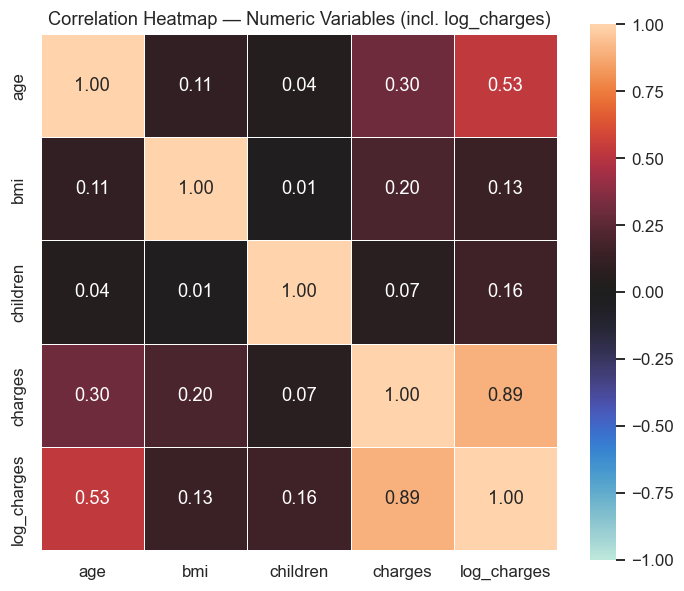

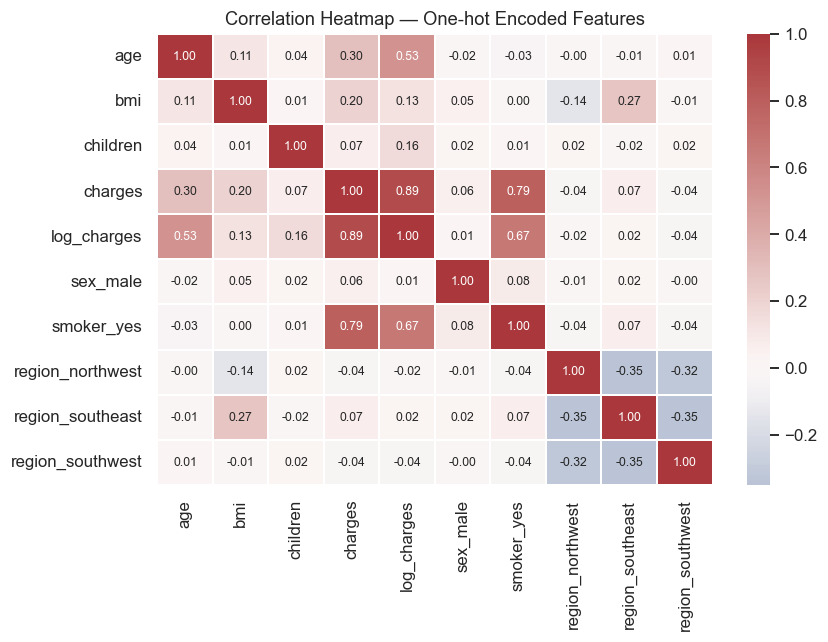

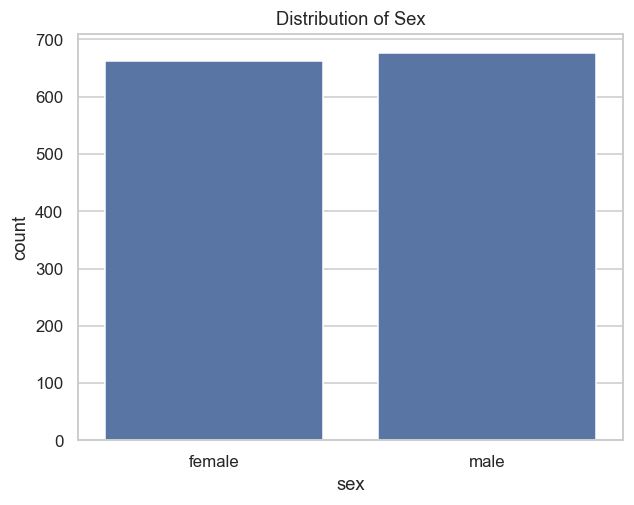

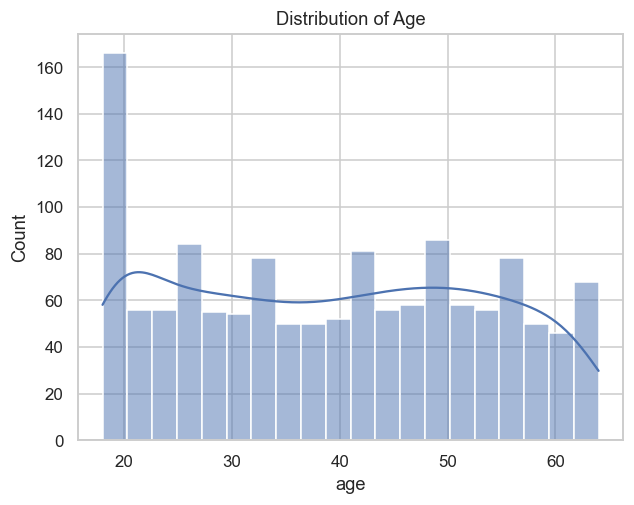

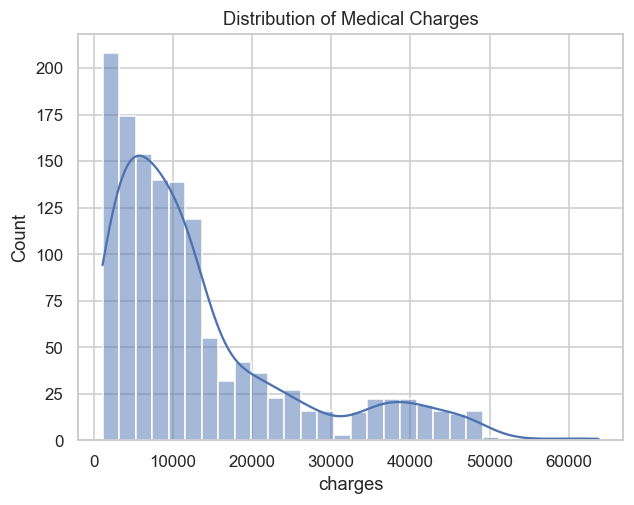

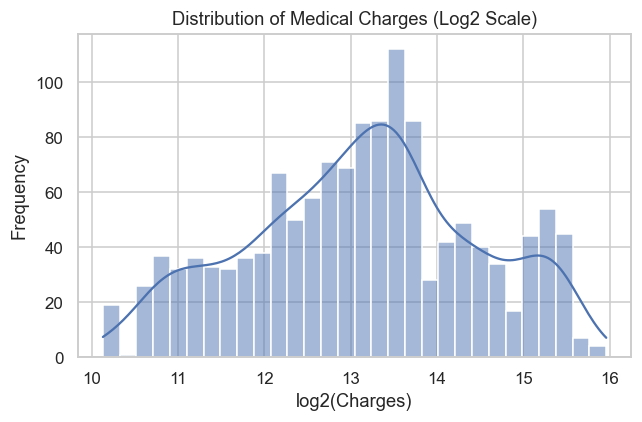

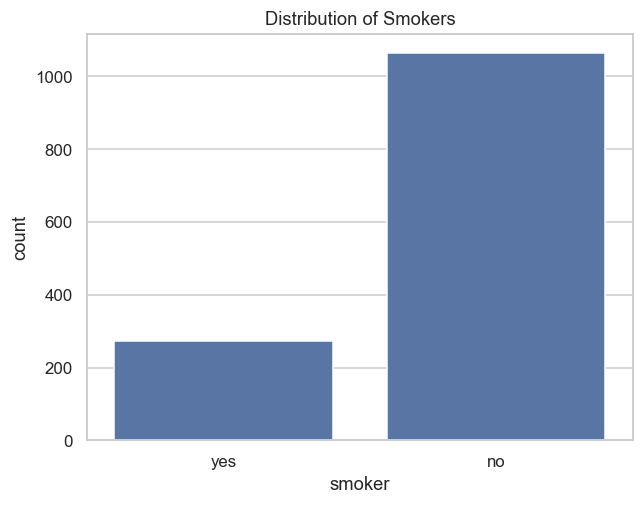

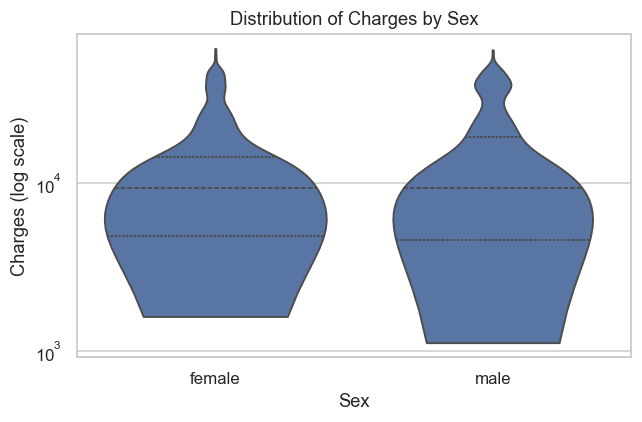

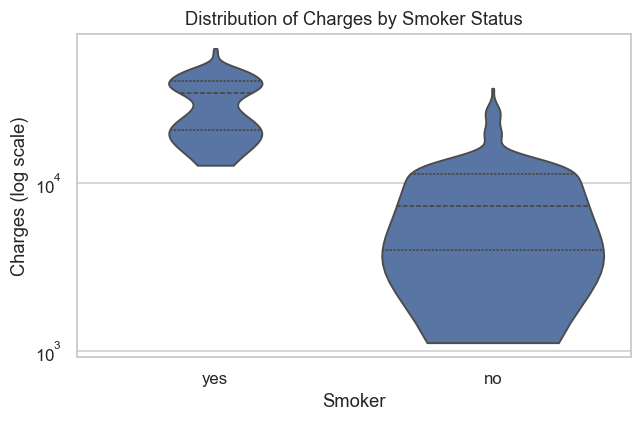

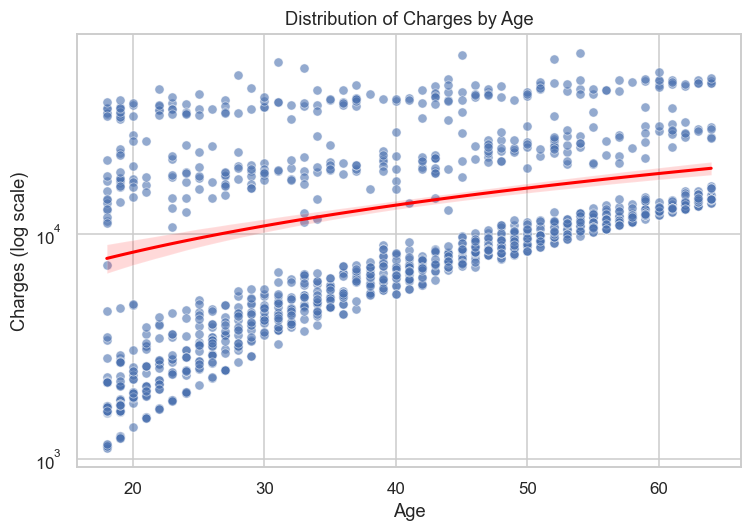

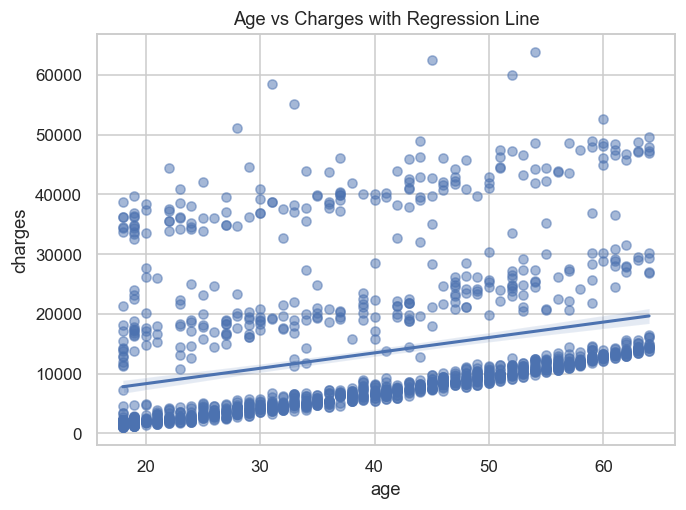

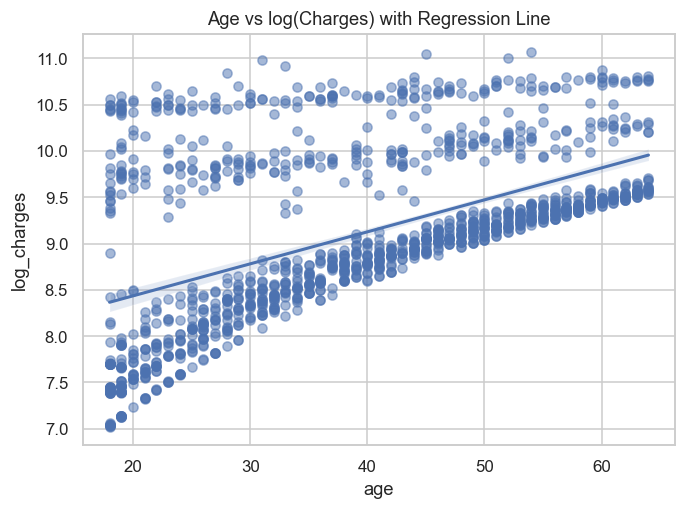


=== Evaluation of Linear Regression Model (smoker, age, bmi) ===
Log-space  -> R²: 0.748 | MAE: 0.302 | RMSE: 0.466
Original $ -> R²: 0.362 | MAE: 5,091.52 | RMSE: 9,813.74
5-fold CV R² (log-space, train): 0.740 ± 0.041


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [ ]:
# Health Analytics — Linear Regression with smoker, age, and BMI as predictors

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Load data

insurance = pd.read_csv("insurance.csv")

sns.set(context="notebook", style="whitegrid")
plt.rcParams["figure.dpi"] = 110


# 1) Variable description

insurance["log_charges"] = np.log(insurance["charges"])

print("\n=== Variables ===")
insurance.info()


# Correlation heatmaps

# Numeric-only heatmap
numeric_df = insurance.select_dtypes(include=np.number)
corr_num = numeric_df.corr().round(3)

plt.figure(figsize=(6.5, 5.5))
sns.heatmap( corr_num, annot=True, fmt=".2f",square=True, cbar=True, vmin=-1, vmax=1, center=0, linewidths=0.5, linecolor="white")
plt.title("Correlation Heatmap — Numeric Variables (incl. log_charges)")
plt.tight_layout()
plt.show()

# One-hot encoded heatmap
insurance_enc = pd.get_dummies(insurance, drop_first=True)
corr_enc = insurance_enc.corr().round(2)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_enc, annot=True, fmt=".2f",cmap="vlag", center=0, cbar=True,linewidths=0.3, linecolor="white", annot_kws={"fontsize":8})
plt.title("Correlation Heatmap — One-hot Encoded Features")
plt.tight_layout()
plt.show()


# Distribution graphs

sns.countplot(data=insurance, x="sex")
plt.title("Distribution of Sex")
plt.show()

sns.histplot(data=insurance, x="age", bins=20, kde=True)
plt.title("Distribution of Age")
plt.show()

sns.histplot(data=insurance, x="charges", bins=30, kde=True)
plt.title("Distribution of Medical Charges")
plt.show()

insurance["log2_charges"] = np.log2(insurance["charges"])

# Plot distribution of log2-transformed charges
plt.figure(figsize=(6,4))
sns.histplot(insurance["log2_charges"], bins=30, kde=True)
plt.title("Distribution of Medical Charges (Log2 Scale)")
plt.xlabel("log2(Charges)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

sns.countplot(data=insurance, x="smoker")
plt.title("Distribution of Smokers")
plt.show()


#  Distributions vs charges

# Sex vs charges
plt.figure(figsize=(6,4))
sns.violinplot(data=insurance, x="sex", y="charges", inner="quartile", cut=0)
plt.yscale("log")
plt.title("Distribution of Charges by Sex")
plt.ylabel("Charges (log scale)")
plt.xlabel("Sex")
plt.tight_layout()
plt.show()

# Smoker vs charges
plt.figure(figsize=(6,4))
sns.violinplot(data=insurance, x="smoker", y="charges", inner="quartile", cut=0)
plt.yscale("log")
plt.title("Distribution of Charges by Smoker Status")
plt.ylabel("Charges (log scale)")
plt.xlabel("Smoker")
plt.tight_layout()
plt.show()

# Age vs charges
plt.figure(figsize=(7,5))
sns.scatterplot(data=insurance, x="age", y="charges", alpha=0.6)
sns.regplot(data=insurance, x="age", y="charges",scatter=False, line_kws={"color":"red", "lw":2})
plt.yscale("log")
plt.title("Distribution of Charges by Age")
plt.ylabel("Charges (log scale)")
plt.xlabel("Age")
plt.tight_layout()
plt.show()

#REGRESSION LINES

sns.regplot(data=insurance, x="age", y="charges",scatter_kws={"alpha": 0.5}, line_kws={"linewidth": 2})
plt.title("Age vs Charges with Regression Line")
plt.tight_layout()
plt.show()

sns.regplot(data=insurance, x="age", y="log_charges",scatter_kws={"alpha": 0.5}, line_kws={"linewidth": 2})
plt.title("Age vs log(Charges) with Regression Line")
plt.tight_layout()
plt.show()


# 6) Train/Test Linear Regression (smoker, age, bmi only)

X = insurance[["smoker", "age", "bmi"]]
y_log = insurance["log_charges"]

preprocess = ColumnTransformer(transformers=[("num", StandardScaler(), ["age", "bmi"]),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), ["smoker"])])

linreg = Pipeline(steps=[ ("preprocess", preprocess), ("model", LinearRegression())])

X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.25, random_state=42)

linreg.fit(X_train, y_train_log)
y_pred_log = linreg.predict(X_test)

# EVALUATION
# Log-space metrics
r2_log = r2_score(y_test_log, y_pred_log)
mae_log = mean_absolute_error(y_test_log, y_pred_log)
rmse_log = mean_squared_error(y_test_log, y_pred_log, squared=False)

# Smearing correction for unbiased back-transform
train_resid = y_train_log - linreg.predict(X_train)
smear = float(np.mean(np.exp(train_resid)))

# Back-transform predictions and ground truth
y_pred = np.exp(y_pred_log) * smear
y_test = np.exp(y_test_log)

# Original-scale metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)

print("\n=== Evaluation of Linear Regression Model (smoker, age, bmi) ===")
print(f"Log-space  -> R²: {r2_log:.3f} | MAE: {mae_log:.3f} | RMSE: {rmse_log:.3f}")
print(f"Original $ -> R²: {r2:.3f} | MAE: {mae:,.2f} | RMSE: {rmse:,.2f}")

# Cross-validation in log-space
cv_scores = cross_val_score(linreg, X_train, y_train_log, cv=5, scoring="r2")
print(f"5-fold CV R² (log-space, train): {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")